# Jupyter Notebook: reading support for electronic devices

## Here's a quick reminder of the documents avalaible in the notebookEP folder, and for what part they're supposed to be used
* carte_ex_coord1 and exemple_coord1: first example of OCR extracted coordinates. Processed by the set up.
* carte_ex_coord2 and exemple_coord2 : second example
* carteTest.jpg, schemaTest.jpg, coord_cart.csv, coord_cicuit.csv : used to test the display step (3.3). 

## Pre processing
Libraries :
- pathlib
- pdf2image
- numpy
- cv2
- ultralytics
- tqdm

In [1]:
import os
import sys
from pathlib import Path
from pdf2image import convert_from_path
import numpy as np
import cv2
from ipywidgets import widgets
from tqdm.notebook import tqdm

from ultralytics import YOLO

#Chargement du modèle entraîné
model = YOLO("./models/extraction/best.pt")
# Changer le chemin si jamais vous n'êtes pas placés dans "notebook"

In [2]:
# À changer. pdf_path est le chemin vers le pdf à convertir et dir_path le chemin pour stocker les résultats
pdf_path = "./notebook_files/Accuphase-E202amp.pdf"
dir_path = "./results"

if not os.path.exists(pdf_path):
    print(f"⚠️ Erreur : Le fichier {pdf_path} est introuvable.")

In [3]:
print("Le traitement est en cours...")
# Commande pour convertir le pdf en images
pages = convert_from_path(pdf_path, dpi=300)

for p_id, page in tqdm(enumerate(pages), total=len(pages), desc="Traitement des pages") :
    page_array = np.array(page)

    # On prédit les classes présentes dans le document
    result = model.predict(source=page, conf=0.212, verbose = False)  # A voir s'il faut ajuster les paramètres

    # On prend le premier car on fait page par page
    for box in result[0].boxes:
        # Récupère les coordonées de la zone
        x, y, y1, x1 = map(int, box.xyxy[0])


        # On ajoute l'image pour qu'elle ne montre que la zone détéctée + une marge au cas où

        margin = 10
        y1_m = max(0, y - margin)
        y2_m = min(page_array.shape[0], y1 + margin)
        x1_m = max(0, x - margin)
        x2_m = min(page_array.shape[1], x1 + margin)

        crop = page_array[y1_m:y2_m, x1_m:x2_m]

        if crop is not None and crop.size > 0:
            # Récupère la classe
            cls = result[0].names[int(box.cls[0])]

            # Sauvegarde de l'image découpée
            filename = f"{Path(pdf_path).stem}_{p_id}_{cls}.png"
            cv2.imwrite(os.path.join(dir_path, filename), crop)

print(f"Le traitement du fichier est terminé")

Le traitement est en cours...


Traitement des pages:   0%|          | 0/20 [00:00<?, ?it/s]

Le traitement du fichier est terminé


À la fin de cette étape tous les fichiers sont stockés dans le répertoire donné.

## Victoire's step (post processing)
Please make sure that the following python modules are include in your virtual environment (or machine) :
* matplotlib
* numpy

This part requires to catch the user's click. To make sure it works for you, **execute the following cell** and check that a red circle gets displayed when you click.

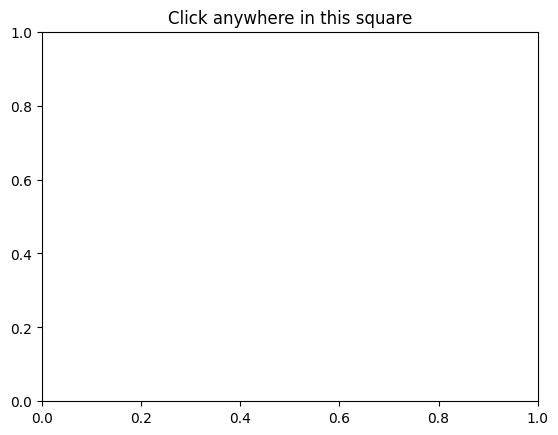

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.set_title("Click anywhere in this square")

def on_click(event):
    if event.inaxes:
        print(f"Clic detected x={event.xdata:.2f}, y={event.ydata:.2f}")
        ax.plot(event.xdata, event.ydata, 'ro')
        fig.canvas.draw()

fig.canvas.mpl_connect('button_press_event', on_click)

plt.show()

If it didn't work, please install this module:


$ pip install ipympl


and execute the following cell :

In [5]:
%matplotlib widget

Now, everything should work properly : 

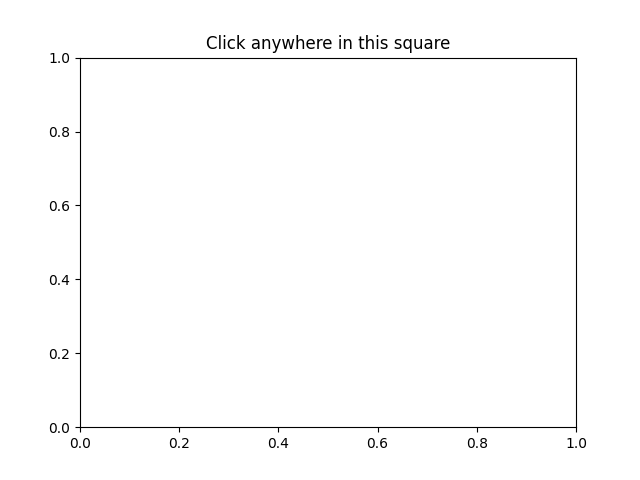

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.set_title("Click anywhere in this square")

def on_click(event):
    if event.inaxes:
        print(f"Clic detected x={event.xdata:.2f}, y={event.ydata:.2f}")
        ax.plot(event.xdata, event.ydata, 'ro')
        fig.canvas.draw()

fig.canvas.mpl_connect('button_press_event', on_click)

plt.show()

In [7]:
import csv
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import imread
from matplotlib.animation import FuncAnimation

Then, it's time for the **set-up**. It's the process that changes the coordinates from (top,height,width,length) to simply (x,y).
The awaited .csv input file must respect these constraints :
* The columns headers are name // left // top // width // height // conf (6 columns)
* Please note that the conf column isn't used in the entire part

In [8]:
# SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP SET-UP
def transformer_csv(input_file: str, output_file: str) :
    # Opening the original file (output from step 2)
    with open(input_file, mode="r", newline="", encoding="utf-8") as infile:
        reader = csv.DictReader(infile)
        # Header of the output csv file
        fieldnames = ["identifiant", "x", "y"]
        # Opening the output file
        with open(output_file, mode="w", newline="", encoding="utf-8") as outfile:
            writer = csv.DictWriter(outfile, fieldnames=fieldnames)
            writer.writeheader()
            for row in reader:
                name = row["name"] # the identifiers' row in the input csv are labelled "name" in the header
                left = float(row["left"])
                top = float(row["top"])
                width = float(row["width"])
                height = float(row["height"])
                x = left + (width / 2)
                y = top + (height / 2)
                # writing in the output file
                writer.writerow({
                    "identifiant": name,
                    "x": x,
                    "y": y
                })


Now, let's clean the identifiers : that's **step 3.1**.
The .csv file whose path is given as an argument should have 3 columns :
identifiant // x // y

In [9]:
# STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1 STEP 3.1

def modif(filepathSource, filepathDest):
    output_rows = [] # dictionnary that contains the cleand rows

    # Pattern : expression that tolerates identifiers of a certains form (letters before numbers that may be separated by commas and/or blank spaces)
    pattern = r'([Cĉƈ<ç©¢ςĆČƇʗζㄈⓒⒸ©ćĈĊċč๔๕€ÇRŕ®ŗřʀŔŖƦЯГ尺ⓡⓇŔŕŖŗŘгѓQҩԳφ٩ҨⓠⓆъьвɓ฿βßƁ乃ⓑⒷţτťŧтŢŤŦ†ｲⓣⓉś§$ŝşѕŚŞŠらⓢⓈ§ŚśŜŝŞşѕĺľŀłℓŁĿĹŁしⓛⓁ£¦ĹĺĻļĽľĿŀŁđδðďÐĎƊのⓓⒹĎďĐđδ₫])\s*(\d+(?:\s*,\s*\d+)*)'

    # Opening the input CSV file
    with open(filepathSource, newline='', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile, delimiter=',', quotechar='"')

        for row in reader: # we go through every row of the input csv file
            if len(row) < 3:
                continue  # Ignoring rows with missing values

            # suppressing blanck spaces from identifiers ; storing them into raw_text, x and y
            raw_text = row[0].strip()
            x = row[1].strip()
            y = row[2].strip()

            # Special case 1 : if the identifier begins with 5, we substituate it to a C
            if re.match(r'^5\s*\d+(?:\s*,\s*\d+)*$', raw_text):
                raw_text = re.sub(r'^5\s*', 'C', raw_text)

            # Special case 2 : if the identifier contains an i, we substituate it to a 1
            raw_text = re.sub(r'i', '1', raw_text, flags=re.IGNORECASE)

            # Searching for valid patterns into our blank free identifiers
            matches = re.findall(pattern, raw_text) # dictionnary
            # ex. matches = [('C', '1,2,3'), ('R', '5'), ('Q', '7')]

            for letter, number_seq in matches: #going through the (letter,number_seq) elements of the dictionnary

                # Interpretating special characters as the corresponding usual letter
                if re.match(r'[Cĉƈ<ç©¢ςĆČƇʗζㄈⓒⒸ©ćĈĊċč๔๕€Ç]', letter, flags=re.IGNORECASE):
                    letter = 'C' # redefine letter as its corrected version
                elif re.match(r'[Rŕ®ŗřʀŔŖƦЯГ尺ⓡⓇŔŕŖŗŘгѓ]', letter, flags=re.IGNORECASE):
                    letter = 'R'
                elif re.match(r'[ҩԳφ٩ҨⓠⓆ]', letter, flags=re.IGNORECASE):
                    letter = 'Q'
                elif re.match(r'[ъьвɓ฿βßƁ乃ⓑⒷ]', letter, flags=re.IGNORECASE):
                    letter = 'B'
                elif re.match(r'[ţτťŧтŢŤŦ†ｲⓣⓉ]', letter, flags=re.IGNORECASE):
                    letter = 'T'
                elif re.match(r'[ś§$ŝşѕŚŞŠらⓢⓈ§ŚśŜŝŞşѕ]', letter, flags=re.IGNORECASE):
                    letter = 'S'
                elif re.match(r'[ĺľŀłℓŁĿĹŁしⓛⓁ£¦ĹĺĻļĽľĿŀŁ]', letter, flags=re.IGNORECASE):
                    letter = 'L'
                elif re.match(r'[đδðďÐĎƊのⓓⒹĎďĐđδ₫]', letter, flags=re.IGNORECASE):
                    letter = 'D'
                else:
                    letter = letter.upper() #casting everything into uppercast

                # Cleaning numbers, including commas and blanck spaces
                numbers = [] # contains the numbers (generally 1) linked to the letter of the identifier
                for n in number_seq.split(','):
                    cleaned = n.strip()  # remove surrounding spaces
                    if cleaned.isdigit():  # keep only if it's a valid integer string
                        numbers.append(cleaned)

                # The identifier is build by concatenating the normalized letter (C, R, Q...) with the corresponding numbers
                # ex. letter "C" and num "2" -> label "C2"
                for num in numbers:
                    label = f"{letter}{num}"
                    output_rows.append([label, x, y]) # recreating the row by adding the memorized coordinates

    # Writing into the output file
    with open(filepathDest, mode='w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile, delimiter=',')
        writer.writerow(['Identifiant', 'x', 'y'])
        writer.writerows(output_rows)


The identifiers are clean : we can merge the two tables (**step 3.2**).


The two input .csv files should have as headers : 
Identifiant // x_cart (resp. x_circ) // y_cart (resp. y_circ)


Since we use the index of the columns and not the header's tag, you can use any tag you want (eg. id instead of identifier)

In [10]:
# STEP 3.2 STEP 3.2 STEP 3.2 STEP 3.2 STEP 3.2 STEP 3.2 STEP 3.2 STEP 3.2 STEP 3.2 STEP 3.2 STEP 3.2 STEP 3.2 STEP 3.2 STEP 3.2 STEP 3.2

def fusionner_csv(circuit_file, carte_file, output_file):
    circuit_data = { } #dictionnary : ex. {"C1": (150, 200), "R5": (300, 400)}
    carte_data = { } # idem

    # Reading the circuit file
    with open(circuit_file, newline='', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter=',')
        for row in reader:
            if len(row) >= 3: # ignoring lines tht aren't conform
                key = row[0].strip() #identifier
                x = row[1].strip()
                y = row[2].strip()
                circuit_data[key] = (x, y)

    # Reading the board file
    with open(carte_file, newline='', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter=',')
        for row in reader:
            if len(row) >= 3:
                key = row[0].strip()
                x = row[1].strip()
                y = row[2].strip()
                carte_data[key] = (x, y)

    # Fusionning data based on common keys (circuit / board)
    # Collect all keys from both dictionaries
    circuit_keys = set(circuit_data.keys())
    carte_keys = set(carte_data.keys())
    # Merge them
    combined_keys = circuit_keys.union(carte_keys)
    # Sort the result
    all_keys = sorted(combined_keys)

    merged_rows = [] # will contain the output rows
    for key in all_keys:
        x_circ, y_circ = circuit_data.get(key, ("", ""))
        # If the key exists → we get the corresponding pair (ex. (150, 200)).
        # If the key doesn't exist → we return the blank pair ("", "").
        x_cart, y_cart = carte_data.get(key, ("", ""))

        merged_rows.append([ #concatenating the data as a row that will be written in the output file
            key,
            x_circ, y_circ,
            x_cart, y_cart
        ])

    # Writing in the output file
    with open(output_file, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f, delimiter=',')
        writer.writerow([
            'Identifiant',
            'x_circ', 'y_circ',
            'x_cart', 'y_cart'
        ])
        writer.writerows(merged_rows)



We can finally display the output : that's **step 3.3**. The .csv input file should have 5 columns : 
Identifiant // x_circ // y_circ // x_cart // y_cart

Once again, you can use the tags you want as they are ignored. But the order matters !

In [11]:
# STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3 STEP 3.3

def afficher_carte_et_schema(carte_img_path, schema_img_path, csv_liaison_path):
    # Loading both images (board et scheme)
    carte = imread(carte_img_path)
    schema = imread(schema_img_path)

    # Lists storing the coordinates
    carte_pts = []
    schema_pts = []

    # Reading the linking .csv file
    with open(csv_liaison_path, newline='', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter=',')
        next(reader, None)  # Ignores the header
        for row in reader:
            if len(row) < 5:
                continue
            try:
                x_circ = float(row[1])
                y_circ = float(row[2])
                x_cart = float(row[3])
                y_cart = float(row[4])

                carte_pts.append([x_cart, y_cart])
                schema_pts.append([x_circ, y_circ])
            except ValueError:
                continue

    # Converts lists into NumPy tables
    carte_pts_np = np.array(carte_pts, dtype=float)
    schema_pts_np = np.array(schema_pts, dtype=float)

    if carte_pts_np.size == 0 or schema_pts_np.size == 0:
        raise ValueError("Aucun point valide trouvé dans le CSV.")

    def trouve_point_proche(x, y, points):
        d = np.sqrt((points[:, 0] - x)**2 + (points[:, 1] - y)**2)
        return np.argmin(d)

    # Prepares the displaying of both the board and the scheme
    fig, (ax_carte, ax_schema) = plt.subplots(1, 2, figsize=(12, 6))
    ax_carte.imshow(carte)
    ax_carte.axis("off")
    ax_schema.imshow(schema)
    ax_schema.axis("off")

    ani = None

    def ease_in_out(t):
        return 0.5 * (1 - np.cos(np.pi * t))

    def anime_zoom(xs, ys, zoom=100, frames=20, interval=30, pause_ms=1000):
        nonlocal ani

        xlim_init = ax_schema.get_xlim()
        ylim_init = ax_schema.get_ylim()

        xlim_target = (xs - zoom, xs + zoom)
        ylim_target = (ys + zoom, ys - zoom)

        pause_frames = int(pause_ms / interval)

        t = np.linspace(0, 1, frames)
        t_eased = ease_in_out(t)

        xlims = xlim_init[0] + (xlim_target[0] - xlim_init[0]) * t_eased
        xlims2 = xlim_init[1] + (xlim_target[1] - xlim_init[1]) * t_eased
        ylims = ylim_init[0] + (ylim_target[0] - ylim_init[0]) * t_eased
        ylims2 = ylim_init[1] + (ylim_target[1] - ylim_init[1]) * t_eased

        xlims = np.concatenate([xlims, np.full(pause_frames, xlim_target[0])])
        xlims2 = np.concatenate([xlims2, np.full(pause_frames, xlim_target[1])])
        ylims = np.concatenate([ylims, np.full(pause_frames, ylim_target[0])])
        ylims2 = np.concatenate([ylims2, np.full(pause_frames, ylim_target[1])])

        t_back = np.linspace(0, 1, frames)
        t_back_eased = ease_in_out(t_back)

        xlims = np.concatenate([xlims, xlim_target[0] + (xlim_init[0] - xlim_target[0]) * t_back_eased])
        xlims2 = np.concatenate([xlims2, xlim_target[1] + (xlim_init[1] - xlim_target[1]) * t_back_eased])
        ylims = np.concatenate([ylims, ylim_target[0] + (ylim_init[0] - ylim_target[0]) * t_back_eased])
        ylims2 = np.concatenate([ylims2, ylim_target[1] + (ylim_init[1] - ylim_target[1]) * t_back_eased])

        def update(i):
            ax_schema.set_xlim(xlims[i], xlims2[i])
            ax_schema.set_ylim(ylims[i], ylims2[i])
            return ax_schema,

        ani = FuncAnimation(fig, update, frames=len(xlims), interval=interval, blit=False, repeat=False)
        plt.draw()

    def on_click(event):
        if event.inaxes != ax_carte:
            return
        if event.xdata is None or event.ydata is None:
            return
        x, y = event.xdata, event.ydata
        idx = trouve_point_proche(x, y, carte_pts_np)
        xs, ys = schema_pts_np[idx]
        anime_zoom(xs, ys, zoom=400, frames=30, interval=30, pause_ms=1000)

    fig.canvas.mpl_connect('button_press_event', on_click)
    plt.show()


## First demo 
Our program's **first demo** simply concatenates the different steps.

In [12]:
transformer_csv("./notebook_files/exemple_coord1.csv", "./../results/output_setup_ex1.csv")  # Set-up (ex 1)
# Les coordonnées de l'exemple 2 sont déjà en x et y (pas besoin de set-up)

    
modif("./../results/output_setup_ex1.csv", "./../results/output_3_1_ex1.csv")               # 3.1 (ex 1)
modif("./notebook_files/exemple_coord2.csv", "./../results/output_3_1_ex2.csv")               # 3.1 (ex 2)
   
    
fusionner_csv(
    "./../results/output_3_1_ex1.csv",
    "./../results/output_3_1_ex2.csv",
    "./../results/output_fusion_exemples_Ilyas.csv"
)                                                         # 3.2

# afficher_carte_et_schema(
    #"carte_ex_coord1.png",
    #"table_ex_coord2.png",
   # "output_fusion_exemples_Ilyas.csv"
#)                                                         # 3.3


On obtient ici une erreur puisque la table et la carte qu'on a données n'ont aucun composé détecté en commun. On ne peut donc faire aucune correspondance.

## Experimental part

The following cells aren't perfect, but they show some things I've tried.

### Displaying several images extracted from the service manual for the user to choose one :

In [13]:
import os
import tkinter as tk
from PIL import Image, ImageTk

def afficher_miniatures(dossier):
    # Variable to store the name of the selected image
    selection = {"nom": None}

    # Create the main window
    root = tk.Tk()
    root.title("Choose an item")

    # Frame to contain the thumbnails
    frame = tk.Frame(root)
    frame.pack(padx=10, pady=10)

    # Sorted list of files
    fichiers = sorted(os.listdir(dossier))
    images = []

    for fichier in fichiers:
        chemin = os.path.join(dossier, fichier)
        if os.path.isfile(chemin):
            try:
                # Create the thumbnail
                img = Image.open(chemin)
                img.thumbnail((300, 300))  # thumbnail size
                photo = ImageTk.PhotoImage(img)
                images.append(photo)

                # Clickable button with the image
                btn = tk.Button(frame, image=photo,
                                command=lambda f=fichier: choisir_image(f, root, selection))
                btn.pack(side="left", padx=5, pady=5)
            except Exception as e:
                print(f"Error with {fichier}: {e}")

    root.mainloop()
    return selection["nom"]

def choisir_image(fichier, root, selection):
    selection["nom"] = fichier
    root.destroy()


And the corresponding main function :

In [14]:
if __name__ == "__main__":
    dossier = "./notebook_files/IMAGES"
    image_choisie = afficher_miniatures(dossier)
    print("Selected image:", image_choisie)

Selected image: 2.jpg


### Checking if one of the images we've retrieved from the service manual contains the component

The function is made to ignore one file : the one on which the user clicked.

In [15]:
def search_word_in_csvs(word, excluded_file):
    found_in = []  # list of filenames where the word is found

    for filename in os.listdir("./notebook_files/"):
        if filename.endswith(".csv") and filename != excluded_file:
            try:
                with open(filename, newline="", encoding="utf-8") as f:
                    reader = csv.reader(f)
                    for row in reader:
                        # Check if the word appears in any cell of the row
                        if any(word in str(cell) for cell in row):
                            found_in.append(filename)
                            break  # no need to read further in this file
            except Exception as e:
                print(f"Error reading {filename}: {e}")

    return found_in


In [16]:

# Example usage:
if __name__ == "__main__":

    print("Test with R8 (present only in exemple_coord.csv)")
    print("Expected output : found in 1 file")
    result = search_word_in_csvs("R8", "example_of_forbidden_file.csv")
    print("The componant was found in the following files:", result)

    print("\n")

    print("Test with R8 (present only in exemple_coord.csv)")
    print("Expected output : found in 0 file")
    result = search_word_in_csvs("R8", "exemple_coord.csv.csv")
    print("The componant was found in the following files:", result)

    print("\n")
    
    print("Test with A (present in two documents)")
    print("Expected output : found in 2 files")
    result = search_word_in_csvs("A", "exemple_coord.csv.csv")
    print("The componant was found in the following files:", result)

    print("\n")
    
    print("Test with A (present in two documents)")
    print("Expected output : found in 1 file")
    result = search_word_in_csvs("A", "coord_circuit.csv")
    print("The componant was found in the following files:", result)


Test with R8 (present only in exemple_coord.csv)
Expected output : found in 1 file
Error reading exemple_coord2.csv: [Errno 2] No such file or directory: 'exemple_coord2.csv'
Error reading exemple_coord.csv: [Errno 2] No such file or directory: 'exemple_coord.csv'
Error reading exemple_coord1.csv: [Errno 2] No such file or directory: 'exemple_coord1.csv'
Error reading coord_circuit.csv: [Errno 2] No such file or directory: 'coord_circuit.csv'
Error reading coord_carte.csv: [Errno 2] No such file or directory: 'coord_carte.csv'
The componant was found in the following files: []


Test with R8 (present only in exemple_coord.csv)
Expected output : found in 0 file
Error reading exemple_coord2.csv: [Errno 2] No such file or directory: 'exemple_coord2.csv'
Error reading exemple_coord.csv: [Errno 2] No such file or directory: 'exemple_coord.csv'
Error reading exemple_coord1.csv: [Errno 2] No such file or directory: 'exemple_coord1.csv'
Error reading coord_circuit.csv: [Errno 2] No such file o

It should then be pretty easy to iterate amond the files found and to display each one facing the file the user chose.

### Function that displays an image and records the closest component to the click

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import csv

def selection_composant(image_path, csv_path):

    img = imread(image_path)

    ids = []
    pts = []

    with open(csv_path, newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            try:
                ids.append(row[0])
                pts.append([float(row[1]), float(row[2])])
            except:
                pass

    points_np = np.array(pts)

    stockage = {"nom": None}

    def point_proche(x, y):
        d = np.sqrt((points_np[:,0]-x)**2 + (points_np[:,1]-y)**2)
        return np.argmin(d)

    fig, ax = plt.subplots()
    ax.imshow(img)
    ax.axis("off")

    def on_click(event):
        if event.inaxes != ax:
            return
        if event.xdata is None or event.ydata is None:
            return

        idx = point_proche(event.xdata, event.ydata)
        stockage["nom"] = ids[idx].upper()
        plt.close(fig)

    fig.canvas.mpl_connect('button_press_event', on_click)
    plt.show()

    return stockage

In [18]:
#resultat = selection_composant("carteTest.jpg", "coord_carte.csv")

In [19]:
#nom_composant = resultat["nom"]
#print("Vous avec choisi le composant " + nom_composant)
#print("Il faut désormais afficher toutes les images qui contiennent ce composant")

Sinon, on peut directement demander à l'utilisateur le composant qu'il veut :

In [20]:
def demander_composant():
    """
    Demande à l'utilisateur de saisir le nom d'un composant,
    et renvoie ce nom en majuscules.
    """
    nom = input("Entrez le nom du composant que vous choisissez : ")
    return nom.upper()

In [21]:
# nom_composant = demander_composant()
# print("Le composant recherché est " + nom_composant)

Un enchaînement d'étapes pourrait ressembler à ça (script bancal) :

In [22]:
# L'utilisateur choisit une image
dossier = "./notebook_files/IMAGES"
image_choisie = afficher_miniatures(dossier) # image qui intéresse l'utilisateur (contient le composant à retrouver)

# L'utilisateur choisit en particulier un composant sur cette image
#composant_choisi = selection_composant(image_choisie, coord_image_choisie) # voir comment on fait le lien entre une image et ses coordonées au sein du dossier
# (ça peut très bien être un autre dossier)

# On récupère les références des csv qui contiennent ce composant dans leurs tables :
#result = search_word_in_csvs(composant_choisi, coord_image_choisie) # On pense à exclure le csv de l'image du début

# On demande à l'utilisateur de choisir l'image qu'il veut parmi celles qui contiennent le composant : 

# On fait le "face à face" comme au S5 :



## Allow the user to add files

Doc : 
https://ipywidgets.readthedocs.io/en/latest/examples/Widget%20List.html

In [23]:
import ipywidgets as widgets
from IPython.display import display

In [24]:
widgets.BoundedIntText(
    value=7,
    min=0,
    max=10,
    step=1,
    description='Text:',
    disabled=False
)

BoundedIntText(value=7, description='Text:', max=10)

In [25]:
widgets.Dropdown(
    options=['1', '2', '3'],
    value='2',
    description='Number:',
    disabled=False,
)

Dropdown(description='Number:', index=1, options=('1', '2', '3'), value='2')

In [26]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
from PIL import Image
import io

uploader = widgets.FileUpload(accept='image/*', multiple=False)
out = widgets.Output()

def afficher_image(change):
    with out:
        out.clear_output()
        for doc in change['new']:
            image = Image.open(io.BytesIO(doc['content']))
            plt.imshow(image)
            plt.axis("off")
            plt.show()

uploader.observe(afficher_image, names='value')

display(widgets.VBox([uploader, out]))

The upload widget exposes a value attribute that contains the files uploaded. The value attribute is a tuple with a dictionary for each uploaded file. 

In [27]:
#for doc in doc_ajoute:
 #   remove_to_keep_git_clean(doc)

## Running the notebook with voila

$ voila NotebookEP.ipynb --Voila.ip=127.0.0.1 --Voila.port=8866

http://127.0.0.1:8866


Cette partie analyse les fichiers au format PDF pour en extraire automatiquement trois types de zones :

- **Table** : tableau BOM (Bill of Materials), c'est-à-dire la liste des composants
- **Diagram** : schéma électronique
- **Board** : carte PCB (circuit imprimé)

Cette partie est composée de trois fichiers qui s'articulent ensemble :

| Fichier | Rôle |
|---|---|
| `prediction.py` | Script autonome : détecte et sauvegarde toutes les zones d'un PDF |
| `merge.py` | Orchestrateur : sélectionne la meilleure zone par classe et lance l'interface |
| `test1.py` | Interface visuelle interactive : affiche et relie les composants détectés |

**Pipeline global :**

```
PDF → conversion en images (pdf2image) → détection de zones (YOLO best.pt)
    → OCR des étiquettes (Tesseract + YOLO bestr.pt) → interface interactive (Matplotlib)
```

**Deux modèles YOLO distincts sont utilisés :**

| Modèle | Utilisé dans | Ce qu'il détecte |
|---|---|---|
| `best.pt` | `prediction.py`, `merge.py` | Grandes zones dans le PDF : Table, Diagram, Board |
| `bestr.pt` | `test1.py` | Petites étiquettes de composants dans les images (R12, C4, Q1…) |

---
## 1. `prediction.py` — Extraction brute des zones

Le script parcourt toutes les pages d'un PDF, détecte les zones via YOLO et sauvegarde chaque découpe en image PNG dans un dossier de sortie. Il ne filtre pas, ne choisit pas : il extrait tout.

**Usage :**
```bash
python3 prediction.py document.pdf /dossier/sortie/
```

### 1.1 Imports et chargement du modèle

On charge le modèle YOLO `best.pt`, entraîné spécifiquement pour reconnaître les trois classes dans des fiches techniques : `Table`, `Diagram`, `Board`.

Les arguments en ligne de commande fournissent le chemin du PDF à analyser et le dossier de destination des images découpées.

In [28]:
import os
import sys
from pathlib import Path
from pdf2image import convert_from_path
import numpy as np
import cv2

from ultralytics import YOLO

# Chargement du modèle entraîné
model_extraction = YOLO("models/extraction/best.pt")

# À adapter selon votre arborescence
pdf_path = 'notebook_files/Accuphase-E202amp.pdf'
dir_path = 'IMAGES'

os.makedirs(dir_path, exist_ok=True)


### 1.2 Conversion du PDF en images

`pdf2image` transforme chaque page du PDF en une image PIL. Le paramètre `dpi=300` garantit une résolution suffisante pour que le texte et les tracés restent lisibles lors de la détection YOLO et de l'OCR qui suivent.

In [29]:
# Conversion du PDF en images (300 DPI)
pages = convert_from_path(pdf_path, dpi=300)
print(f"{len(pages)} page(s) trouvée(s).")


20 page(s) trouvée(s).


### 1.3 Détection YOLO et découpe des zones

Pour chaque page, YOLO prédit les boîtes englobantes (`bounding boxes`) avec un seuil de confiance de `0.212` (valeur basse car le modèle est spécialisé et les faux positifs sont rares).

Chaque zone détectée est découpée dans l'image de la page avec une marge de 10 pixels de chaque côté pour ne pas rogner les bords, puis sauvegardée en PNG. Le nom du fichier encode le nom du PDF source, le numéro de page et la classe détectée.

In [30]:
for p_id, page in enumerate(pages):
    page_array = np.array(page)

    # Prédiction YOLO page par page
    result = model_extraction.predict(source=page, conf=0.212, verbose=False)

    for box in result[0].boxes:
        # Coordonnées de la zone détectée
        x, y, y1, x1 = map(int, box.xyxy[0])

        # Découpe avec marge
        margin = 10
        y1_m = max(0, y - margin)
        y2_m = min(page_array.shape[0], y1 + margin)
        x1_m = max(0, x - margin)
        x2_m = min(page_array.shape[1], x1 + margin)

        crop = page_array[y1_m:y2_m, x1_m:x2_m]

        if crop is not None and crop.size > 0:
            cls = result[0].names[int(box.cls[0])]
            filename = f"{Path(pdf_path).stem}_{p_id}_{cls}.png"
            cv2.imwrite(os.path.join(dir_path, filename), crop)

print("Le traitement du fichier est terminé.")


Le traitement du fichier est terminé.


---
## 3. `test1.py` — Interface interactive de visualisation

Le but du script est de fournir une interface Matplotlib qui affiche côte à côte la table BOM, le schéma et la carte PCB, et permet de **cliquer sur un composant** (ex: `R12`) pour le localiser dans les trois images simultanément.

Il utilise deux moteurs de détection selon le type d'image :
- **Tesseract seul** pour la table BOM (texte structuré en colonnes)
- **YOLO + Tesseract** pour le schéma et la carte (étiquettes petites et dispersées)

**Usage standalone :**
```bash
python3 test1.py table.png schema.png carte.png
```

### 3.1 Imports, configuration et constantes

Le script tente de forcer le backend graphique `TkAgg` pour Matplotlib (nécessaire sur certains systèmes Linux/Mac pour afficher une fenêtre interactive). Le chargement du modèle `best_table.pt` est fait au niveau module — si le fichier est absent, le script s'arrête immédiatement.

Le READER EasyOCR est chargé une seule fois au démarrage pour optimiser les performances.
On utilise une "Allowlist" pour éviter que le moteur ne confonde des composants avec des caractères spéciaux inutiles (symboles mathématiques, ponctuation complexe, etc.).

`PREFIXES_VALIDES` liste les codes normalisés des composants électroniques : `R` = résistance, `C` = condensateur, `U` = circuit intégré, `D` = diode, `Q` = transistor, `L` = inductance, etc.

In [31]:
import cv2
import re
import sys
import time
import numpy as np
from ultralytics import YOLO
import matplotlib
try:
    matplotlib.use('TkAgg')
except Exception:
    pass
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors

import easyocr

print("  ⟳  Chargement EasyOCR...", end='', flush=True)
_t0 = time.time()
READER = easyocr.Reader(
    ['en', 'fr', 'de', 'es', 'it', 'nl', 'pt'],
    gpu=True, verbose=False
)
print(f"  ✔  EasyOCR prêt  ({time.time() - _t0:.1f}s)")

ALLOWLIST    = 'ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789-_'
OCR_CONF_MIN = 0.15

PATH_TO_YOLO_MODEL = "models/best_table.pt"

try:
    yolo_model = YOLO(PATH_TO_YOLO_MODEL)
    print("Modèle YOLO chargé.")
except Exception as e:
    print(f"Erreur chargement YOLO : {e}")
    sys.exit(1)

PREFIXES_VALIDES = ['R', 'C', 'U', 'D', 'Q', 'L', 'J', 'SW', 'F', 'TP', 'RV', 'Y', 'DZ', 'IC']

  ⟳  Chargement EasyOCR...  ✔  EasyOCR prêt  (2.1s)
Modèle YOLO chargé.


Cette partie du code implémente un pipeline complet de correction et de validation des références électroniques extraites par OCR à partir d’images (typiquement des schémas ou PCB). L’objectif est de transformer un texte bruité produit par l’OCR en une référence fiable comme `R516`, `C401`, `IC402`, etc.

L’OCR confond très ხშირად certains caractères visuellement proches. Pour corriger cela, deux dictionnaires sont utilisés :

* `PREFIX_FIXES` : corrige les chiffres mal reconnus dans la partie **préfixe** (ex : `0` → `O`, `1` → `I`)
* `DIGIT_FIXES` : corrige les lettres mal reconnues dans la partie **numérique** (ex : `O` → `0`, `I` → `1`, `S` → `5`)

Ces corrections sont appliquées différemment selon la position du caractère dans la chaîne.


2. Fonction `fix_ocr_confusion`

Cette fonction corrige intelligemment une chaîne OCR en respectant la structure typique d’une référence électronique :

1. Nettoyage du texte :

   * suppression des espaces
   * conversion en majuscules

2. Détection de la frontière entre :

   * le **préfixe** (lettres, ex : `R`, `C`, `IC`)
   * la **partie numérique** (ex : `516`)

3. Séparation éventuelle d’un **suffixe lettre** (ex : `A` dans `R516A`)

4. Application des corrections :

   * sur le préfixe → utilisation de `PREFIX_FIXES`
   * sur les chiffres → utilisation de `DIGIT_FIXES`

Exemples :

* `R51G` → `R516`
* `C41J` → `C411`
* `0C402` → `OC402`


3. Corrections spécifiques (`POST_CORRECTIONS`)

Même après correction générale, certaines erreurs OCR sont récurrentes et spécifiques.
Le dictionnaire `POST_CORRECTIONS` permet de corriger ces cas connus.

Exemples :

* `UC402` → `IC402`
* `RSI9` → `R519`
* `BCI78` → `BC178`

La fonction `apply_post_corrections` applique ces corrections après le traitement principal.


4. Validation des références (`COMPONENT_PATTERN`)

Une expression régulière (`regex`) est utilisée pour vérifier si une chaîne correspond à une vraie référence électronique.

Formats acceptés :

* `R516`, `C401`, `IC402A`
* `BC178`, `TP12`
* `R123-45`

La fonction `is_valid_ref` retourne `True` si la chaîne est valide, sinon `False`.


5. Prétraitement des images

Deux méthodes sont utilisées pour améliorer la qualité avant OCR :

* `preprocess_crop_clahe` :

  * agrandissement de l’image
  * accentuation (sharpening)
  * amélioration du contraste avec CLAHE

* `preprocess_crop_otsu` :

  * binarisation automatique (Otsu)
  * utile pour les images sombres ou inversées


6. OCR avec EasyOCR (`_run_easyocr`)

Cette fonction :

* lance EasyOCR sur l’image
* filtre les résultats par confiance minimale
* nettoie les textes (suppression espaces, majuscules)
* trie les résultats par score


7. Pipeline OCR complet (`run_ocr_on_crop`)

Cette fonction applique plusieurs stratégies successives pour maximiser la détection :

1. OCR sur image prétraitée (CLAHE)
2. Si échec :

   * rotation 90° (utile pour textes verticaux)
3. Si encore échec :

   * méthode Otsu

À chaque étape :

* correction OCR
* validation du format

Elle retourne :

* le texte corrigé
* un booléen de validité
* le score de confiance


8. Fusion de boîtes (`merge_nearby_boxes`)

YOLO peut détecter une même référence en plusieurs morceaux (ex : `R` et `516`).
Cette fonction fusionne les boîtes proches si :

* elles sont alignées verticalement
* la distance horizontale est faible
* elles ne se chevauchent pas

Le but est de reconstruire une seule zone pour améliorer l’OCR.

In [32]:
PREFIX_FIXES = {'0': 'O', '1': 'I', '8': 'B', '6': 'G', '5': 'S'}
DIGIT_FIXES  = {
    'I': '1', 'J': '1', 'L': '1', '|': '1',
    'O': '0', 'Q': '0', 'D': '0',
    'G': '6', 'Z': '2', 'S': '5', 'B': '8', 'T': '7',
}

POST_CORRECTIONS = {
    'UC402': 'IC402', 'UC405': 'IC405',
    'RSI9':  'R519',  'RL26':  'R126',
    'S501':  'C501',  'B178':  'BC178',
    'BCI78': 'BC178', 'BCI7':  'BC17',
    'CI7A':  'C17A',  'LC41':  'C41',
    'ECN8':  'C8',    'IB6':   'B6',
    'REO7':  'R07',   'JEC740':'C740',
    'STLO1': 'ST01',  'R62I':  'R621',
    'C41J':  'C411',  'C50G':  'C506',
    'R5122': 'R512',  'BC1788':'BC178',
    'BC178B':'BC178', 'T5502': 'T502',
}

COMPONENT_PATTERN = re.compile(
    r'^('
    r'[A-Z]{1,2}\s?\d{3,5}[A-Z]?'
    r'|[A-Z]{1,3}\d{2,5}[A-Z]?'
    r'|[A-Z]{2,4}\d{1,4}[A-Z]?'
    r'|St\s?\d{3}'
    r'|[A-Z]{1,3}\d+[-_]\d+'
    r')$',
    re.IGNORECASE
)


def fix_ocr_confusion(text: str) -> str:
    """Corrige confusions chiffres/lettres selon position préfixe/numérique."""
    if not text:
        return text
    text = text.strip().upper().replace(' ', '')
    i = 0
    while i < len(text) and not text[i].isdigit():
        i += 1
    if i == len(text):
        return text
    prefix_raw = text[:i]
    rest = text[i:]
    if len(rest) > 1 and rest[-1].isalpha():
        suffix, digits_raw = rest[-1], rest[:-1]
    else:
        suffix, digits_raw = '', rest
    fixed_prefix = ''.join(PREFIX_FIXES.get(ch, ch) if ch.isdigit() else ch for ch in prefix_raw)
    fixed_digits = ''.join(ch if ch.isdigit() else DIGIT_FIXES.get(ch, ch) for ch in digits_raw)
    return fixed_prefix + fixed_digits + suffix


def apply_post_corrections(text: str) -> str:
    key = text.strip().upper().replace(' ', '')
    return POST_CORRECTIONS.get(key, text)


def is_valid_ref(text: str) -> bool:
    return bool(COMPONENT_PATTERN.match(text.strip()))


def preprocess_crop_clahe(crop_bgr, scale=4):
    """Upscale + netteté + CLAHE pour EasyOCR."""
    h, w = crop_bgr.shape[:2]
    big  = cv2.resize(crop_bgr, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)
    k    = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    sharp = cv2.filter2D(big, -1, k)
    gray  = cv2.cvtColor(sharp, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    bgr = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)
    return cv2.copyMakeBorder(bgr, 10, 10, 10, 10, cv2.BORDER_CONSTANT, value=(255, 255, 255))


def preprocess_crop_otsu(crop_bgr, scale=4):
    """Variante Otsu — meilleure sur fond sombre."""
    h, w = crop_bgr.shape[:2]
    big  = cv2.resize(crop_bgr, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(big, cv2.COLOR_BGR2GRAY)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    bgr = cv2.cvtColor(bw, cv2.COLOR_GRAY2BGR)
    return cv2.copyMakeBorder(bgr, 10, 10, 10, 10, cv2.BORDER_CONSTANT, value=(255, 255, 255))

def _run_easyocr(img_bgr):
    """Lance EasyOCR et retourne la liste (text, conf) triée par confiance."""
    try:
        results = READER.readtext(
            img_bgr, detail=1, paragraph=False,
            allowlist=ALLOWLIST,
            width_ths=0.7,
        )
    except Exception:
        return []
    out = []
    for (_, text, conf) in results:
        if conf < OCR_CONF_MIN:
            continue
        t = text.strip().upper()
        t = re.sub(r'\s+', '', t)
        if t:
            out.append((t, conf))
    return sorted(out, key=lambda x: x[1], reverse=True)


def run_ocr_on_crop(crop_bgr, scale=4):
    """
    Essaie CLAHE → CLAHE+rotation → Otsu.
    Retourne (text_corrigé, is_valid, conf).
    """
    def best_from(img):
        hits = _run_easyocr(img)
        if not hits:
            return "", False, 0.0
        for (t, c) in hits:
            fixed = apply_post_corrections(fix_ocr_confusion(t))
            if is_valid_ref(fixed):
                return fixed, True, c
        fixed = apply_post_corrections(fix_ocr_confusion(hits[0][0]))
        return fixed, False, hits[0][1]

    pre_clahe = preprocess_crop_clahe(crop_bgr, scale=scale)
    h, w = pre_clahe.shape[:2]
    text, valid, conf = best_from(pre_clahe)
    if valid:
        return text, valid, conf

    # Tentative rotation 90° (labels verticaux fréquents sur les schémas)
    if h > w * 1.3 or not text:
        t2, v2, c2 = best_from(cv2.rotate(pre_clahe, cv2.ROTATE_90_CLOCKWISE))
        if v2 or (t2 and c2 > conf):
            text, valid, conf = t2, v2, c2
    if valid:
        return text, valid, conf

    # Fallback Otsu
    pre_otsu = preprocess_crop_otsu(crop_bgr, scale=scale)
    t3, v3, c3 = best_from(pre_otsu)
    if v3 or (t3 and c3 > conf):
        return t3, v3, c3

    return text, valid, conf

def merge_nearby_boxes(boxes, gap_ratio=0.8, overlap_y_ratio=0.4):
    """Fusionne les boîtes YOLO proches qui correspondent au même label."""
    if not boxes:
        return boxes
    boxes = sorted(boxes, key=lambda b: b[0])
    merged = list(boxes)
    changed = True
    while changed:
        changed = False
        new_merged = []
        used = [False] * len(merged)
        for i in range(len(merged)):
            if used[i]:
                continue
            b1 = merged[i]
            x1a, y1a, x2a, y2a, ca = b1
            best_j, best_gap = -1, float('inf')
            for j in range(i + 1, len(merged)):
                if used[j]:
                    continue
                x1b, y1b, x2b, y2b, cb = merged[j]
                if x1b < x2a:
                    continue
                h_avg  = ((y2a - y1a) + (y2b - y1b)) / 2
                gap    = x1b - x2a
                if gap > gap_ratio * h_avg:
                    continue
                overlap_y = min(y2a, y2b) - max(y1a, y1b)
                min_h     = min(y2a - y1a, y2b - y1b)
                if min_h == 0 or overlap_y / min_h < overlap_y_ratio:
                    continue
                if gap < best_gap:
                    best_gap, best_j = gap, j
            if best_j >= 0:
                x1b, y1b, x2b, y2b, cb = merged[best_j]
                new_merged.append((min(x1a, x1b), min(y1a, y1b),
                                   max(x2a, x2b), max(y2a, y2b),
                                   (ca + cb) / 2))
                used[i] = used[best_j] = True
                changed = True
            else:
                new_merged.append(b1)
                used[i] = True
        merged = new_merged
    return merged

### 3.2 `natural_sort_key()` — tri naturel des références

Un tri alphabétique classique produirait `R1, R10, R11, R2` (car `'1' < '2'` mais `'10' < '2'` en comparaison de chaînes). Le tri naturel compare les parties numériques comme des entiers, donnant l'ordre correct : `R1, R2, R10, R11`.

La fonction découpe la chaîne en alternant segments texte et segments numériques, puis compare chaque segment dans son type propre.

In [33]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

### 3.3 `clean_ocr_text()` — correction des erreurs OCR

L'OCR fait souvent des erreurs visuelles sur les petites polices des schémas. Cette fonction applique un pipeline de corrections en 4 étapes :

1. **Nettoyage** : ne garder que les caractères alphanumériques majuscules (supprimer ponctuation, espaces, caractères parasites)
2. **Extraction du préfixe** : chercher un préfixe valide dans le texte. Les préfixes sont triés par longueur décroissante pour matcher `SW` avant `S`, `IC` avant `I`, etc.
3. **Correction des confusions visuelles** : `S→5`, `A→4`, `O→0`, `I→1`, `L→1`, `Z→2`, `G→6`, `B→8`
4. **Suppression des zéros de tête** : `Q010 → Q10`, `R001 → R1`

Si aucun préfixe valide n'est trouvé, la fonction retourne `None` pour indiquer que le texte ne correspond pas à une référence de composant.

In [34]:
def clean_ocr_text(text):
    """
    Nettoyage strict : 
    1. AR4 -> R4 (Suppression préfixes fantômes)
    2. Q010 -> Q10 (Suppression zéros de remplissage)
    3. RS -> R5 (Correction confusions visuelles)
    """
    t = re.sub(r'[^A-Z0-9]', '', text.upper())
    
    found_prefix = None
    remaining_part = ""
    
    for p in sorted(PREFIXES_VALIDES, key=len, reverse=True):
        match = re.search(r'(' + p + r')([A-Z0-9]+)', t)
        if match:
            found_prefix = match.group(1)
            remaining_part = match.group(2)
            break
    
    if found_prefix:
        suffix = remaining_part.replace('S', '5').replace('A', '4').replace('O', '0')
        suffix = suffix.replace('I', '1').replace('L', '1').replace('Z', '2')
        suffix = suffix.replace('G', '6').replace('B', '8')
        
        num_match = re.search(r'\d+', suffix)
        if num_match:
            num_str = num_match.group().lstrip('0')
            if not num_str: num_str = "0"
            return found_prefix + num_str
            
    return None

### 3.4 `preprocess_for_ocr()` — préparation d'une image pour Tesseract

Tesseract donne de bien meilleurs résultats sur des images :
- **en niveaux de gris** (pas de couleur à interpréter)
- **agrandies** (le texte des étiquettes est souvent très petit)
- **binarisées** (uniquement noir ou blanc, pas de nuances de gris)

La binarisation utilise la méthode d'Otsu : elle calcule automatiquement le seuil optimal qui sépare le fond du texte, sans paramètre à régler manuellement. Le paramètre `factor` contrôle le niveau d'agrandissement (3× par défaut, 4× pour les très petites étiquettes).

In [35]:
def preprocess_for_ocr(img, factor=3):
    """ Prépare une petite zone de l'image pour Tesseract """
    if img.size == 0: return img
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=factor, fy=factor, interpolation=cv2.INTER_CUBIC)
    return cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

### 3.5 `detect_refs_table()` — analyse de la table (BOM)

Dans une table de nomenclature (BOM), les références de composants sont généralement organisées en colonnes, souvent avec une structure implicite :

- les préfixes (`R`, `C`, `Q`, etc.) ne sont pas toujours répétés à chaque ligne  
- certaines lignes contiennent uniquement des numéros (ex : `516`, `517`)  
- la qualité OCR dépend fortement de la résolution de l’image  

Cette fonction implémente une approche optimisée pour extraire correctement ces références malgré ces contraintes.


#### 1. Isolation de la colonne des références

On commence par extraire uniquement la partie gauche de l’image :

- environ **22% de la largeur** (`w * 0.22`)  
- correspond typiquement à la colonne contenant les références  

**Objectif :** réduire le bruit et limiter l’OCR à la zone pertinente.


#### 2. Amélioration de la résolution (zoom ×2)

L’image est agrandie avec un facteur `scale = 2` :

- interpolation `INTER_CUBIC` pour conserver la qualité  
- améliore fortement la lisibilité pour l’OCR  

**Objectif :** faciliter la reconnaissance des petits caractères.


#### 3. Lecture OCR avec EasyOCR

Le modèle EasyOCR (`READER`) est utilisé pour lire le texte :

- `detail=1` : retourne les bounding boxes + texte + confiance  
- `paragraph=False` : traitement ligne par ligne  
- `allowlist` : limite les caractères possibles (lettres + chiffres)

Les résultats sont ensuite **triés verticalement** (de haut en bas) pour respecter l’ordre de lecture.


#### 4. Gestion intelligente des préfixes

Les tables BOM utilisent souvent une notation compacte :

- `R516`
- `517`
- `518`

Ici, seules les premières lignes contiennent le préfixe (`R`), les suivantes ne contiennent que des chiffres.

La fonction gère cela avec une **mémoire de préfixe** :

- `last_prefix` est initialisé à `"R"` (valeur par défaut)
- si une ligne commence par des lettres → mise à jour du préfixe
- sinon :
  - si la ligne contient des chiffres → on concatène avec le dernier préfixe connu

Exemples :
- `R516` → préfixe = `R`
- `517` → devient `R517`
- `C401` → préfixe devient `C`


#### 5. Nettoyage et filtrage des résultats

Pour chaque texte détecté :

- conversion en majuscules  
- suppression des espaces  
- filtrage par seuil de confiance (`OCR_CONF_MIN`)  

Les lignes sans contenu exploitable sont ignorées.


#### 6. Calcul des coordonnées

Les coordonnées retournées par EasyOCR sont calculées sur l’image agrandie.

On les **ramène à l’échelle originale** en divisant par `scale`.

Pour chaque référence, on calcule :

- `bbox` : boîte englobante `(x1, y1, x2, y2)`  
- `cx`, `cy` : centre de la boîte  


#### 7. Construction des résultats

Chaque référence est stockée sous forme de dictionnaire :

- `ref` : texte final (ex : `R516`)  
- `bbox` : coordonnées de la zone  
- `cx`, `cy` : position centrale  

In [36]:
def detect_refs_table(img):
    """
    Version améliorée : Zoom x2 + mémoire du préfixe pour éviter les oublis.
    """
    if img is None: return []
    h, w = img.shape[:2]
    
    # 1. On isole la colonne des refs (environ 22% de la largeur)
    crop = img[:, :int(w * 0.22)]
    
    # 2. AMÉLIORATION IMAGE : On double la taille pour aider l'OCR
    scale = 2
    big = cv2.resize(crop, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    
    # 3. LECTURE OCR
    # On utilise ton READER global déjà initialisé
    results = READER.readtext(big, detail=1, paragraph=False, allowlist=ALLOWLIST)
    
    # Tri vertical pour garantir qu'on lit de haut en bas
    results.sort(key=lambda x: x[0][0][1])

    found_refs = []
    last_prefix = "R" # Préfixe par défaut (souvent Résistance)

    for (bbox_pts, text, conf) in results:
        if conf < OCR_CONF_MIN: continue
        
        # Nettoyage du texte lu
        raw_text = text.upper().replace(' ', '')
        
        # LOGIQUE DE PRÉFIXE : 
        # On cherche si la ligne commence par des lettres (ex: R, C, Q)
        prefix_match = re.match(r'^([A-Z]+)', raw_text)
        
        if prefix_match:
            current_prefix = prefix_match.group(1)
            # On stocke ce préfixe pour les lignes suivantes qui n'en auraient pas
            last_prefix = current_prefix 
            clean_text = raw_text
        else:
            # Si on ne lit que des chiffres, on rajoute le dernier préfixe connu
            if re.search(r'\d+', raw_text):
                clean_text = f"{last_prefix}{raw_text}"
            else:
                continue

        # Calcul des coordonnées (on divise par 'scale' pour revenir à la taille originale)
        xs = [p[0]/scale for p in bbox_pts]
        ys = [p[1]/scale for p in bbox_pts]
        
        # On remplit ton dictionnaire exactement comme avant pour ne pas casser l'affichage
        found_refs.append({
            "ref": clean_text,
            "bbox": (min(xs), min(ys), max(xs), max(ys)),
            "cx": np.mean(xs),
            "cy": np.mean(ys)
        })
            
    return found_refs


### 3.6 `detect_refs_easyocr()` — analyse du schéma et de la carte

Pour les schémas électroniques et les cartes PCB, les références de composants (ex : `R516`, `C401`, `IC402`) sont souvent :

- très petites  
- fragmentées en plusieurs morceaux  
- orientées différemment  
- noyées dans un environnement visuel complexe  

Une approche OCR globale serait trop bruitée et inefficace. On adopte donc une pipeline robuste en plusieurs étapes combinant détection et lecture ciblée.

---

#### 1. Localisation des zones de texte avec YOLO

Le modèle **YOLO** est utilisé pour détecter les régions de l’image contenant potentiellement des références :

- `conf=0.20` : seuil de confiance relativement bas pour ne pas rater de petites zones  
- `imgsz=1280` : résolution élevée pour améliorer la détection des petits éléments  

Chaque détection produit une boîte englobante `(x1, y1, x2, y2)` associée à un score de confiance (`yolo_conf`).

Ces boîtes sont stockées dans `raw_boxes`.

---

#### 2. Fusion des boîtes fragmentées

YOLO peut parfois découper une même référence en plusieurs morceaux (ex : `R` et `516` détectés séparément).

La fonction `merge_nearby_boxes()` fusionne les boîtes proches si :

- elles sont alignées verticalement  
- elles sont suffisamment proches horizontalement  

**Objectif :** reconstruire une zone complète correspondant à une seule référence (`"R516"`).

---

#### 3. Extraction des sous-images (cropping)

Pour chaque boîte fusionnée :

- on extrait une sous-image (`crop`) de la zone détectée  
- un padding (`PAD = 5`) est ajouté pour éviter de couper du texte  

Les zones vides ou invalides sont ignorées.

---

#### 4. Lecture OCR avec correction (`run_ocr_on_crop`)

Chaque crop est analysé avec une pipeline OCR avancée :

- EasyOCR lit le texte  
- plusieurs prétraitements sont testés (CLAHE, rotation, Otsu)  
- les erreurs OCR sont corrigées (ex : `O → 0`, `I → 1`)  
- le texte est validé via une regex de références électroniques  

**Résultat pour chaque zone :**

- `text` : texte corrigé  
- `valid` : indique si la référence est valide  
- `ocr_conf` : score de confiance OCR  

---

#### 5. Construction des détections

Chaque référence détectée est stockée sous forme de dictionnaire contenant :

- `ref` : texte final (ex : `R516`)  
- `is_valid` : validité du format  
- `yolo_conf` : confiance de la détection  
- `ocr_conf` : confiance OCR  
- `cx`, `cy` : centre de la boîte (utile pour positionnement spatial)  
- `bbox` : coordonnées de la boîte  

---

#### 6. Déduplication des références

Une même référence peut être détectée plusieurs fois dans l’image.

Un mécanisme de déduplication est appliqué :

- chaque référence est identifiée par une clé normalisée (uppercase, sans espaces)  
- un score global est calculé :  
  `score = yolo_conf × ocr_conf`  
- si une référence apparaît plusieurs fois, seule la détection avec le meilleur score est conservée  

---

#### 7. Résultat final

La fonction retourne une liste de références uniques et fiables, chacune associée à :

- sa position dans l’image  
- sa confiance  
- sa validité  

In [37]:
def detect_refs_easyocr(img):
    """
    Analyse du Schéma ou de la Carte :
      1. YOLO localise les zones de texte (où ?)
      2. EasyOCR lit chaque zone avec correcteur OCR (quoi ?)
    Remplace l'ancien detect_refs_hybrid.
    """
    if img is None:
        return []

    results = yolo_model.predict(source=img, conf=0.20, imgsz=1280, verbose=False)
    PAD = 5
    raw_boxes = []
    for result in results:
        for box in result.boxes:
            b = box.xyxy[0].cpu().numpy().astype(int)
            raw_boxes.append((b[0], b[1], b[2], b[3], float(box.conf[0])))

    # Fusion des boîtes fragmentées (ex: "R" + "516" → "R516")
    boxes = merge_nearby_boxes(raw_boxes)

    found_refs = []
    for (x1, y1, x2, y2, conf_yolo) in boxes:
        crop = img[max(0, y1 - PAD):y2 + PAD, max(0, x1 - PAD):x2 + PAD]
        if crop.size == 0:
            continue
        text, valid, ocr_conf = run_ocr_on_crop(crop, scale=4)
        if text:
            found_refs.append({
                "ref":        text,
                "is_valid":   valid,
                "yolo_conf":  round(conf_yolo, 3),
                "ocr_conf":   round(ocr_conf, 3),
                "cx":         float((x1 + x2) / 2),
                "cy":         float((y1 + y2) / 2),
                "bbox":       (float(x1), float(y1), float(x2), float(y2)),
            })

    # Déduplication : garder la détection avec le meilleur score par référence
    seen = {}
    deduped = []
    for d in found_refs:
        key = d["ref"].upper().replace(' ', '')
        score = d["yolo_conf"] * d["ocr_conf"]
        if key not in seen:
            seen[key] = len(deduped)
            deduped.append(d)
        else:
            existing_score = deduped[seen[key]]["yolo_conf"] * deduped[seen[key]]["ocr_conf"]
            if score > existing_score:
                deduped[seen[key]] = d

    return deduped

### 3.7 `afficher()` — construction de l'interface Matplotlib

C'est le point d'entrée de l'interface. Elle charge les images, lance les détections sur chacune, puis construit la figure Matplotlib avec 3 ou 4 panneaux selon si la carte est fournie.

Les résultats des détections sont stockés dans des dictionnaires `{référence: infos}` (ex: `{"R12": {"cx": 450, "cy": 230, "bbox": (...)}}`). Cela permet une recherche en O(1) lors des interactions.

In [38]:
def afficher(table_path, schema_path, carte_path=None):
    img_t = cv2.imread(table_path)
    img_s = cv2.imread(schema_path)
    img_c = cv2.imread(carte_path) if carte_path else None

    print("  ⟳  Analyse en cours...")
    t0 = time.time()

    # Table : EasyOCR colonne gauche
    dict_table  = {r["ref"]: r for r in detect_refs_table(img_t)}
    # Schéma : YOLO + EasyOCR
    dict_schema = {r["ref"]: r for r in detect_refs_easyocr(img_s)}
    # Carte  : YOLO + EasyOCR (si fournie)
    dict_carte  = {r["ref"]: r for r in detect_refs_easyocr(img_c)} if img_c is not None else {}

    print(f"  ✔  Bilan ({time.time()-t0:.1f}s) : "
          f"Table({len(dict_table)}) | Schéma({len(dict_schema)}) | Carte({len(dict_carte)})")

    # ── Mise en page ────────────────────────────────────────
    fig  = plt.figure(figsize=(18, 9))
    cols = 4 if img_c is not None else 3
    gs   = fig.add_gridspec(1, cols, width_ratios=[1.2, 2, 2, 2][:cols])

    ax_list   = fig.add_subplot(gs[0, 0])
    ax_table  = fig.add_subplot(gs[0, 1])
    ax_schema = fig.add_subplot(gs[0, 2])
    ax_carte  = fig.add_subplot(gs[0, 3]) if img_c is not None else None
    axes_images = [ax for ax in [ax_table, ax_schema, ax_carte] if ax is not None]

    ax_table.imshow(cv2.cvtColor(img_t, cv2.COLOR_BGR2RGB))
    ax_schema.imshow(cv2.cvtColor(img_s, cv2.COLOR_BGR2RGB))
    if ax_carte is not None:
        ax_carte.imshow(cv2.cvtColor(img_c, cv2.COLOR_BGR2RGB))

    ax_table.set_title("Table (BOM)",   fontsize=11)
    ax_schema.set_title("Schéma",       fontsize=11)
    if ax_carte is not None:
        ax_carte.set_title("Carte PCB", fontsize=11)

    for ax in [ax_list] + axes_images:
        ax.axis("off")

    # ── Liste des refs (panneau gauche) ─────────────────────
    ids     = sorted(dict_table.keys(), key=natural_sort_key)
    colors  = list(mcolors.TABLEAU_COLORS.values())
    text_mapping, y_pos, last_prefix, color_idx = {}, 0.98, None, 0

    for ident in ids:
        m = re.match(r'([A-Z]+)', ident)
        prefix = m.group(1) if m else "?"
        if prefix != last_prefix:
            if last_prefix:
                y_pos -= 0.02
            ax_list.text(0.05, y_pos, f"--- {prefix} ---",
                         fontsize=10, fontweight='bold', alpha=0.7,
                         transform=ax_list.transAxes)
            y_pos -= 0.03
            color_idx = (color_idx + 1) % len(colors)

        txt_obj = ax_list.text(0.15, y_pos, ident,
                               fontsize=9, picker=5, fontweight='bold',
                               color=colors[color_idx],
                               transform=ax_list.transAxes)
        text_mapping[txt_obj] = ident
        last_prefix = prefix
        y_pos -= 0.025
        if y_pos < 0.02:
            break

    # ── Rectangles de focus ─────────────────────────────────
    rects    = {ax: patches.Rectangle((0, 0), 0, 0, edgecolor="red",
                                       facecolor="none", linewidth=2, visible=False)
                for ax in axes_images}
    for ax in axes_images:
        ax.add_patch(rects[ax])
    orig_lims = {ax: (ax.get_xlim(), ax.get_ylim()) for ax in axes_images}

    def do_focus(ident):
        zoom  = 350
        found = False
        dicts = {ax_table: dict_table, ax_schema: dict_schema}
        if ax_carte is not None:
            dicts[ax_carte] = dict_carte

        for ax, dic in dicts.items():
            if ident in dic:
                info = dic[ident]
                ax.set_xlim(info["cx"] - zoom, info["cx"] + zoom)
                ax.set_ylim(info["cy"] + zoom, info["cy"] - zoom)
                b = info["bbox"]
                rects[ax].set_xy((b[0], b[1]))
                rects[ax].set_width(b[2] - b[0])
                rects[ax].set_height(b[3] - b[1])
                rects[ax].set_visible(True)
                found = True
            else:
                rects[ax].set_visible(False)

        if found:
            fig.suptitle(f"Focus : {ident}", color="red", fontsize=16, fontweight="bold")
            plt.draw()

    def on_click(event):
        if event.button == 3:   # clic droit → reset zoom
            for ax in axes_images:
                ax.set_xlim(orig_lims[ax][0])
                ax.set_ylim(orig_lims[ax][1])
                rects[ax].set_visible(False)
            fig.suptitle("")
            plt.draw()
        elif event.inaxes in axes_images and event.button == 1:
            dicts = {ax_table: dict_table, ax_schema: dict_schema}
            if ax_carte is not None:
                dicts[ax_carte] = dict_carte
            curr_dict = dicts.get(event.inaxes)
            if curr_dict:
                pts = np.array([[r["cx"], r["cy"]] for r in curr_dict.values()])
                if len(pts) > 0:
                    dist = np.linalg.norm(pts - [event.xdata, event.ydata], axis=1)
                    idx  = np.argmin(dist)
                    if dist[idx] < 200:
                        do_focus(list(curr_dict.keys())[idx])

    fig.canvas.mpl_connect("pick_event",         lambda e: do_focus(text_mapping[e.artist]))
    fig.canvas.mpl_connect("button_press_event",  on_click)
    fig.canvas.mpl_connect("scroll_event",        lambda e: on_scroll(e, axes_images))

    print("  ✔  Interface prête.")
    plt.tight_layout()
    plt.show()


def on_scroll(event, axes_images):
    if event.inaxes not in axes_images:
        return
    ax    = event.inaxes
    scale = 1 / 1.5 if event.button == 'up' else 1.5
    cur_xlim, cur_ylim = ax.get_xlim(), ax.get_ylim()
    new_w = (cur_xlim[1] - cur_xlim[0]) * scale
    new_h = (cur_ylim[1] - cur_ylim[0]) * scale
    ax.set_xlim([event.xdata - new_w / 2, event.xdata + new_w / 2])
    ax.set_ylim([event.ydata + new_h / 2, event.ydata - new_h / 2])
    plt.draw()


### 3.8 Panneau de liste cliquable

Les composants de la table BOM sont affichés sous forme de texte Matplotlib dans le panneau de gauche. Le paramètre `picker=5` rend chaque texte cliquable (zone de 5px autour du texte). Les composants sont groupés par préfixe et colorés par groupe (10 couleurs distinctes issues de `TABLEAU_COLORS`).

`text_mapping` associe chaque objet texte Matplotlib à son identifiant de composant — indispensable pour savoir sur quel composant l'utilisateur a cliqué dans le callback `pick_event`.

### 3.9 Rectangles de focus et fonction `do_focus()`

Un rectangle `patches.Rectangle` invisible est pré-créé pour chaque panneau image. Quand `do_focus()` est appelée avec un identifiant de composant, elle :
1. Cherche le composant dans chaque dictionnaire
2. Si trouvé : zoome le panneau autour de la position du composant (`set_xlim` / `set_ylim`), repositionne et rend visible le rectangle rouge
3. Si absent de ce panneau : masque le rectangle

Note : en Matplotlib, l'axe Y est inversé par rapport aux coordonnées image (origine en haut), d'où `set_ylim(cy + zoom, cy - zoom)` pour zoomer correctement.

### 3.10 Gestion des événements souris

Trois types d'interactions sont disponibles dans l'interface :

| Interaction | Effet |
|---|---|
| Clic gauche sur la liste | Zoom sur le composant dans les 3 images + rectangle rouge |
| Clic gauche sur une image | Trouve le composant le plus proche du clic (distance euclidienne < 200px) |
| Clic droit n'importe où | Réinitialise toutes les vues à leur niveau de zoom original |
| Molette sur une image | Zoom libre centré sur la position du curseur (×1.5 par cran) |

La recherche du composant le plus proche utilise `np.linalg.norm` pour calculer la distance euclidienne entre le point cliqué et tous les centres de composants connus, puis `np.argmin` pour trouver le plus proche.

### 3.11 `on_scroll()` — zoom à la molette

Le zoom est implémenté en redimensionnant les limites de l'axe autour du point pointé par le curseur. Un facteur 1.5 est appliqué à chaque cran de molette. Scroll vers le haut = zoom avant (division par 1.5), scroll vers le bas = zoom arrière (multiplication par 1.5).

---
## 2. `merge.py` — Orchestration de la lecture des images

Ce script est une version améliorée de `prediction.py`. Au lieu de sauvegarder toutes les détections, il ne conserve que **la meilleure zone par classe** (celle avec la plus grande surface en pixels), applique des rotations si nécessaire, puis lance l'interface interactive de `test1.py`.

**Usage :**
```bash
python3 merge.py Accuphase-E202amp.pdf ../../../models/extraction/best.pt
```

### 2.1 Imports et import de l'interface

### 2.2 Fonction principale `process_and_visualize()`

Toute la logique est encapsulée dans cette fonction. Elle reçoit le chemin du PDF et le chemin du modèle YOLO, et orchestre les 4 étapes suivantes.

#### Étape 1 & 2 : Chargement du modèle et conversion du PDF

Identique à `prediction.py` : le modèle YOLO est chargé, puis le PDF est converti page par page en images PIL à 300 DPI.

In [39]:
import os
import sys
import cv2
import numpy as np
from pdf2image import convert_from_path
from ultralytics import YOLO

# afficher() doit déjà être définie (section test1.py ci-dessus)


#### Étape 2 : Sélection de la meilleure zone par classe

Le dictionnaire `best_images` stocke pour chaque classe un tuple `(image_découpée, surface_en_pixels)`. À chaque nouvelle détection, on calcule la surface (`largeur × hauteur`) et on ne garde la découpe que si elle est plus grande que celle déjà enregistrée. Ainsi, à la fin du parcours de toutes les pages, on a retenu la zone la plus grande pour chaque type.

In [40]:
def process_and_visualize(pdf_path, model_path):
    # 1. Chargement du modèle de zones (prediction.py)
    try:
        model = YOLO(model_path)
    except Exception as e:
        print(f"Erreur chargement modèle : {e}")
        return

    # 2. Conversion PDF en images (DPI 300)
    print("--- Conversion du PDF en images ---")
    pages = convert_from_path(pdf_path, dpi=300)
    
    best_images = {"Table": (None, 0), "Diagram": (None, 0), "Board": (None, 0)}

    print("--- Extraction des zones via YOLO ---")
    for p_id, page in enumerate(pages):
        # Utilisation directe du format PIL pour la détection comme dans prediction.py
        results = model.predict(source=page, conf=0.212, verbose=False)
        page_array = np.array(page)

        for box in results[0].boxes:
            cls_name = results[0].names[int(box.cls[0])]
            
            # Mapping vers nos clés
            key = None
            if cls_name.lower() == "table": key = "Table"
            elif cls_name.lower() == "diagram": key = "Diagram"
            elif cls_name.lower() == "board": key = "Board"

            if key:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                
                # Découpage avec marge de 10px
                margin = 10
                y1_m, y2_m = max(0, y1 - margin), min(page_array.shape[0], y2 + margin)
                x1_m, x2_m = max(0, x1 - margin), min(page_array.shape[1], x2 + margin)
                
                crop = page_array[y1_m:y2_m, x1_m:x2_m]
                
                if crop is not None and crop.size > 0:
                    surface = crop.shape[0] * crop.shape[1]
                    if surface > best_images[key][1]:
                        best_images[key] = (crop, surface)

    # 3. Traitement, Rotations et Sauvegarde
    temp_paths = {}
    for cls in ["Table", "Diagram", "Board"]:
        img_data, surf = best_images[cls]
        if img_data is not None:
            # Conversion RGB vers BGR pour OpenCV
            img_to_save = cv2.cvtColor(img_data, cv2.COLOR_RGB2BGR)

            # --- APPLICATION DES ROTATIONS ---
            if cls == "Diagram":
                # Rotation 90° vers la GAUCHE (Counter-Clockwise)
                print("Rotation du Schéma (90° gauche)...")
                img_to_save = cv2.rotate(img_to_save, cv2.ROTATE_90_COUNTERCLOCKWISE)
            
            elif cls == "Board":
                # Rotation 90° vers la DROITE (Clockwise)
                print("Rotation de la Carte (90° droite)...")
                img_to_save = cv2.rotate(img_to_save, cv2.ROTATE_90_CLOCKWISE)

            path = f"temp_{cls.lower()}.png"
            cv2.imwrite(path, img_to_save)
            temp_paths[cls] = path
 
    if "Table" in temp_paths and "Diagram" in temp_paths:
        print(f"--- Affichage ---")
        afficher(
            temp_paths["Table"], 
            temp_paths["Diagram"], 
            temp_paths.get("Board")
        )
    else:
        print("\nERREUR : 'Table' ou 'Diagram' manquant.")
        print(f"Trouvés : {[k for k, v in best_images.items() if v[0] is not None]}")
        

#### Étape 3 : Rotations et sauvegarde temporaire

Les schémas et cartes sont souvent orientés en mode paysage dans les PDFs. On les redresse avant affichage :

- `Diagram` → rotation 90° **gauche** (counter-clockwise)
- `Board` → rotation 90° **droite** (clockwise)  
- `Table` → aucune rotation

On effectue aussi la conversion de couleurs **RGB → BGR**, nécessaire car PIL produit des images en RGB tandis qu'OpenCV (`cv2.imwrite`) attend du BGR.

#### Étape 4 : Lancement de l'interface

`Table` et `Diagram` sont obligatoires pour que l'interface ait du sens. `Board` est optionnel — `.get()` retourne `None` sans lever d'erreur si la clé est absente, et `afficher()` gère ce cas.

In [42]:
# Lancement du pipeline complet
# Modifiez les chemins selon votre configuration
PDF_PATH = "notebook_files/Accuphase-E202amp.pdf"
MODEL_PATH = "models/extraction/best.pt"

process_and_visualize(PDF_PATH, MODEL_PATH)


--- Conversion du PDF en images ---
--- Extraction des zones via YOLO ---
Rotation du Schéma (90° gauche)...
Rotation de la Carte (90° droite)...
--- Affichage ---
  ⟳  Analyse en cours...
  ✔  Bilan (34.1s) : Table(39) | Schéma(228) | Carte(40)
  ✔  Interface prête.
